In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Wrap_to_pbc)=
# Wrap to PBC

*Wrapping atomic coordinates into the primary periodic boundary condition unit cell.*

The function {func}`molsysmt.pbc.wrap_to_pbc` maps atomic coordinates back into the primary space-filling periodic unit cell.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.pbc.wrap_to_pbc`.
:::


## Basic usage

Let's wrap a continuous trajectory into the primary periodic box:


In [2]:
import molsysmt as msm
import numpy as np
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['two LJ particles']['traj_two_lj_particles.trjpk'], to_form='molsysmt.StructuresDict')


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We inspect the continuous particle coordinate trajectory before wrapping:


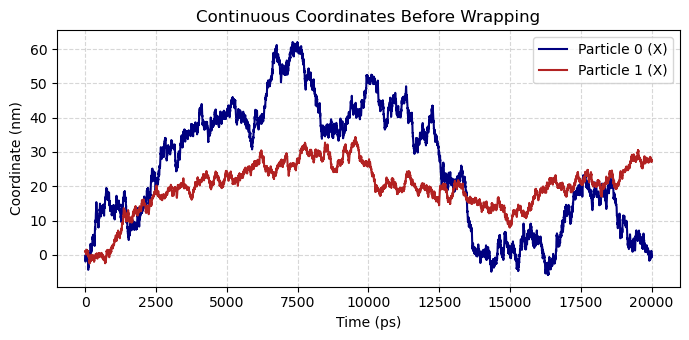

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
time = molsys['time']
ax.plot(time, molsys['coordinates'][:, 0, 0], label='Particle 0 (X)', color='navy')
ax.plot(time, molsys['coordinates'][:, 1, 0], label='Particle 1 (X)', color='firebrick')
ax.set_title('Continuous Coordinates Before Wrapping')
ax.set_xlabel('Time (ps)')
ax.set_ylabel('Coordinate (nm)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


We fold all atomic coordinates into the primary periodic unit cell with {func}`molsysmt.pbc.wrap_to_pbc`:


In [5]:
molsys_wrapped = msm.pbc.wrap_to_pbc(molsys)


Plotting the wrapped coordinates confirms that all coordinates now evolve strictly within the periodic cell boundaries:


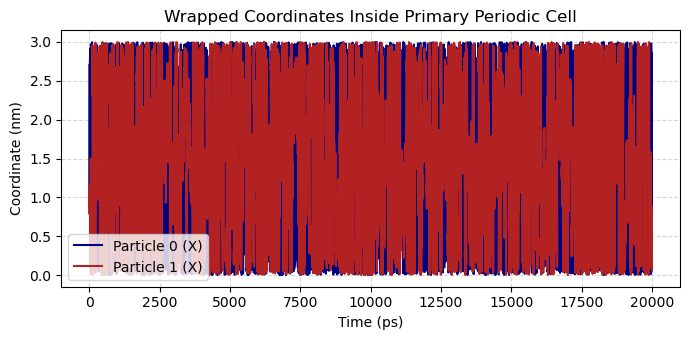

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(time, molsys_wrapped['coordinates'][:, 0, 0], label='Particle 0 (X)', color='navy')
ax.plot(time, molsys_wrapped['coordinates'][:, 1, 0], label='Particle 1 (X)', color='firebrick')
ax.set_title('Wrapped Coordinates Inside Primary Periodic Cell')
ax.set_xlabel('Time (ps)')
ax.set_ylabel('Coordinate (nm)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


We verify that inter-particle distances evaluated under periodic boundary conditions remain invariant under wrapping:


In [7]:
dist_orig = msm.structure.get_distances(molsys, selection=0, selection_2=1, pbc=True)
dist_wrap = msm.structure.get_distances(molsys_wrapped, selection=0, selection_2=1, pbc=True)
print('Periodic distances invariant under wrapping:', np.allclose(dist_orig, dist_wrap))


Periodic distances invariant under wrapping: True


## Preserving covalent bonds during macromolecular wrapping

When wrapping macromolecular structures containing bonded atoms (such as solvated proteins or peptides), setting `compact='component'` ensures connected covalent blocks are reconstructed and translated together:


In [8]:
molsys_pep = msm.convert(msm.systems['Met-enkephalin']['met_enkephalin.h5msm'])
molsys_solv = msm.build.solvate(molsys_pep, box_shape='cubic', clearance='14.0 angstroms', engine='PDBFixer')
molsys_pep_wrapped = msm.pbc.wrap_to_pbc(molsys_solv, compact='component')


We visualize the wrapped solvated macromolecular system in 3D:


In [9]:
molsysviewer_htmlfile = '_static/views/tools_pbc_wrap_to_pbc_1.html'


In [10]:
msm.view(molsys_pep_wrapped)


'<iframe src="../../../../_static/views/tools_pbc_wrap_to_pbc_1.html" width="100%" height="480px"\n        style="border:none;"></iframe>'

:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems with {func}`molsysmt.basic.convert`.
- {ref}`Solvate <Tutorial_Solvate>`: Solvate molecular systems with {func}`molsysmt.build.solvate`.
- {ref}`Get distances <Tutorial_Get_distances>`: Measure structural distances with {func}`molsysmt.structure.get_distances`.
- {ref}`View <Tutorial_View>`: Render 3D molecular views with {func}`molsysmt.basic.view`.
- {ref}`Wrap to MIC <Tutorial_Wrap_to_mic>`: Wrap to minimum image convention with {func}`molsysmt.pbc.wrap_to_mic`.
- {ref}`Unwrap <Tutorial_Unwrap>`: Restore spatial continuity with {func}`molsysmt.pbc.unwrap`.
:::
